In [ ]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from itertools import combinations
from sklearn.metrics import roc_curve, auc

c:\Users\xiaox\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "..", "data")
RESULTS_DIR = os.path.join(ROOT_DIR, "..", "results")
meta = pd.read_csv(os.path.join(DATA_DIR, "participants.tsv"), sep="\t")

In [19]:
def append_meta_data(results):
    """
    Append metadata to results dictionary.

    Args:
        results (dict): Dictionary containing model results with subject IDs.
    
    Returns:
        dict: Updated results dictionary with appended metadata.
    """
    results["subject_metadata"] = {}

    for fold in results["outer_folds"]:
        for subject_id in np.unique(fold["test_subject_id"]):
            subject_meta = meta[meta["participant_id"] == subject_id].iloc[0]
            results["subject_metadata"][subject_id] = {
                "gender": subject_meta["Gender"],
                "age": subject_meta["Age"],
                "group": subject_meta["Group"]
            }
    return results

In [4]:
def get_all_roc(results):
    """
    Compile ROC curve data across all outer folds.
    
    Args:
        results (dict): Dictionary containing outer fold results 
        with true labels and predicted probabilities.
    
    Returns:
        fpr (np.array): False positive rates.
        tpr (np.array): True positive rates.
        auc_val (float): Area under the ROC curve.
    """
    all_y_true = []
    all_y_prob = []

    for fold in results["outer_folds"]:
        all_y_true.extend(fold["true_labels"])
        all_y_prob.extend(fold["pred_probs"])

    all_y_true = np.array(all_y_true)
    all_y_prob = np.array(all_y_prob)

    fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
    auc_val = auc(fpr, tpr)

    return fpr, tpr, auc_val

In [35]:
def get_all_accuracy(results):
    """
    Compile test accuracies across all outer folds.
    
    Args:
        results (dict): Dictionary containing outer fold results 
        with true labels and predicted labels.
    
    Returns:
        accuracies (list): List of test accuracies for each outer fold.
    """
    accuracies = []

    for fold in results["outer_folds"]:
        acc = fold["test_accuracy"]
        subject_id = fold["test_subject_id"]
        group = results["subject_metadata"][subject_id]["group"]

        accuracies.append({
            "test_accuracy": acc,
            "test_subject_id": subject_id,
            "subject_group": group
        })

    return accuracies

AD vs. CN task

In [5]:
# Load all results
with open(os.path.join(RESULTS_DIR, "EEGNet_A_C/C_A/all_results.pkl"), "rb") as f:
    eegnet_ad = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "OptunaCNN/alpha/C_A/all_results.pkl"), "rb") as f:
    cnn_ad = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "PretrainedAlexNet/alpha/C_A/final_complete_all_folds.pkl"), "rb") as f:
    alexnet_ad = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "PretrainedVGG16/alpha/C_A/all_results.pkl"), "rb") as f:
    vgg_ad = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "PretrainedResNet18/alpha/C_A/all_results.pkl"), "rb") as f:
    resnet_ad = pickle.load(f)

In [20]:
# Append metadata to results
eegnet_ad = append_meta_data(eegnet_ad)
cnn_ad = append_meta_data(cnn_ad)
alexnet_ad = append_meta_data(alexnet_ad)
vgg_ad = append_meta_data(vgg_ad)
resnet_ad = append_meta_data(resnet_ad)

In [21]:
models_ad = {
    "EEGNet": eegnet_ad,
    "CNN": cnn_ad,
    "VGG16": vgg_ad,
    "ResNet18": resnet_ad,
    "AlexNet": alexnet_ad
}

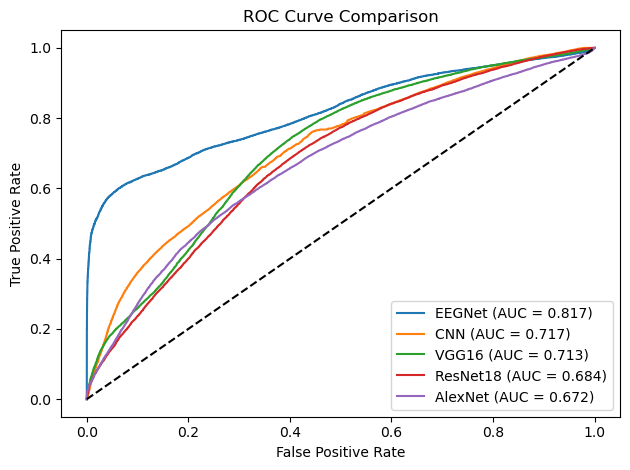

In [22]:
# Plot ROC curves
for model_name, results in models_ad.items():
    fpr, tpr, auc_val = get_all_roc(results)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.legend(loc='lower right')
plt.savefig("figures/AD_CN_models_ROC_curve_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [70]:
# Compile test accuracies across models
models_ad = {
    "EEGNet": eegnet_ad,
    "CNN": cnn_ad,
    "AlexNet": alexnet_ad,
    "VGG16": vgg_ad,
    "ResNet18": resnet_ad
}

df_accuracy = []

for model_name, results in models_ad.items():
    test_accuracies = get_all_accuracy(results)

    df_acc = pd.DataFrame(test_accuracies)
    df_acc["model"] = model_name
    df_acc["subject_group"] = df_acc["subject_group"].replace({"A": "AD", "C": "CN"})
    
    df_accuracy.append(df_acc)

df_all = pd.concat(df_accuracy, ignore_index=True)
df_all.head()

,test_accuracy,test_subject_id,subject_group,model
0,1.000000,sub-001,AD,EEGNet
1,0.253165,sub-002,AD,EEGNet
2,0.736842,sub-003,AD,EEGNet
3,1.000000,sub-004,AD,EEGNet
4,0.987531,sub-005,AD,EEGNet


C:\Users\xiaox\AppData\Local\Temp\ipykernel_38036\2466464300.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_all, x="model", y="test_accuracy", estimator="mean", errorbar="se", capsize=0.1, palette=palette,alpha=0.7)
C:\Users\xiaox\AppData\Local\Temp\ipykernel_38036\2466464300.py:12: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=df_all, x="model", y="test_accuracy", estimator="mean", errorbar="se", capsize=0.1, palette=palette,alpha=0.7)


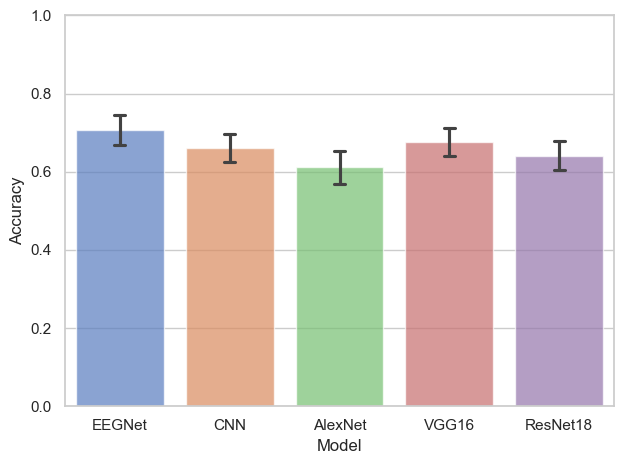

In [77]:
# Bar plot of model accuracies
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.0
)

sns.set_theme(style="whitegrid")

palette = sns.color_palette("muted")

sns.barplot(data=df_all, x="model", y="test_accuracy", estimator="mean", errorbar="se", capsize=0.1, palette=palette,alpha=0.7)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.savefig("figures/Model_Comparison_AD_CN_Accuracies_Barplot.pdf", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

C:\Users\xiaox\AppData\Local\Temp\ipykernel_38036\3374583460.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_all, x="test_accuracy", y="model", palette=model_palette, cut=0, inner="box", linewidth=1, density_norm='width')


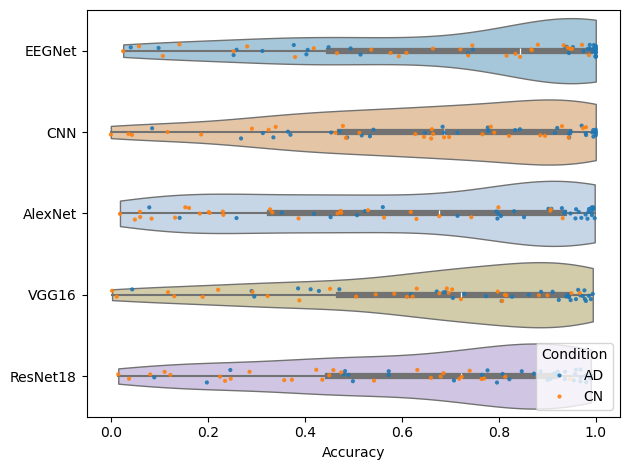

In [ ]:
# Violin plot grouped by subject condition
model_palette = {
    "EEGNet":   "#9ecae1",
    "CNN":      "#eec69c",
    "AlexNet":  "#c1d6ec",
    "VGG16":    "#d9d0a3",
    "ResNet18": "#cfc1e8"
    
}

dot_palette = {
    "AD": "#1f77b4",
    "CN": "#ff7f0e"
}

sns.violinplot(data=df_all, x="test_accuracy", y="model", palette=model_palette, cut=0, inner="box", linewidth=1, density_norm="width")
sns.stripplot(data=df_all, x="test_accuracy", y="model", hue="subject_group", palette=dot_palette, size=3, jitter=0.08, alpha=0.9)
plt.xlabel("Accuracy")
plt.ylabel("")
plt.legend(title="Condition", loc="lower right")
plt.tight_layout()
plt.savefig("figures/final_violin_grouped.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
# Statistical comparison using Wilcoxon signed-rank test for paired samples
df_wide = df_all.pivot(index="test_subject_id", columns="model", values="test_accuracy")
for model_a, model_b in combinations(df_wide.columns, 2):
    stat, p = wilcoxon(df_wide[model_a], df_wide[model_b])
    print(f"{model_a} vs {model_b}: Wilcoxon statistic = {stat:.4f}, p = {p:.4f}")

AlexNet vs CNN: Wilcoxon statistic = 824.0000, p = 0.1486
AlexNet vs EEGNet: Wilcoxon statistic = 580.0000, p = 0.0021
AlexNet vs ResNet18: Wilcoxon statistic = 860.0000, p = 0.2287
AlexNet vs VGG16: Wilcoxon statistic = 630.0000, p = 0.0097
CNN vs EEGNet: Wilcoxon statistic = 623.0000, p = 0.0316
CNN vs ResNet18: Wilcoxon statistic = 943.0000, p = 0.5165
CNN vs VGG16: Wilcoxon statistic = 943.0000, p = 0.6563
EEGNet vs ResNet18: Wilcoxon statistic = 613.0000, p = 0.0043
EEGNet vs VGG16: Wilcoxon statistic = 675.0000, p = 0.0146
ResNet18 vs VGG16: Wilcoxon statistic = 707.0000, p = 0.0260


FTD vs. CN task

In [62]:
# Load all results
with open(os.path.join(RESULTS_DIR, "EEGNet_F_C/C_F/all_results.pkl"), "rb") as f:
    eegnet_ftd = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "OptunaCNN/alpha/C_F/all_results.pkl"), "rb") as f:
    cnn_ftd = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "PretrainedAlexNet/alpha/C_F/all_results.pkl"), "rb") as f:
    alexnet_ftd = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "PretrainedVGG16/alpha/C_F/all_results.pkl"), "rb") as f:
    vgg_ftd = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "PretrainedResNet18/alpha/C_F/all_results.pkl"), "rb") as f:
    resnet_ftd = pickle.load(f)

In [63]:
# Append metadata to results
eegnet_ftd = append_meta_data(eegnet_ftd)
cnn_ftd = append_meta_data(cnn_ftd)
alexnet_ftd = append_meta_data(alexnet_ftd)
vgg_ftd = append_meta_data(vgg_ftd)
resnet_ftd = append_meta_data(resnet_ftd)

In [64]:
models_ftd = {
    "EEGNet": eegnet_ftd,
    "CNN": cnn_ftd,
    "AlexNet": alexnet_ftd,
    "VGG16": vgg_ftd,
    "ResNet18": resnet_ftd
}

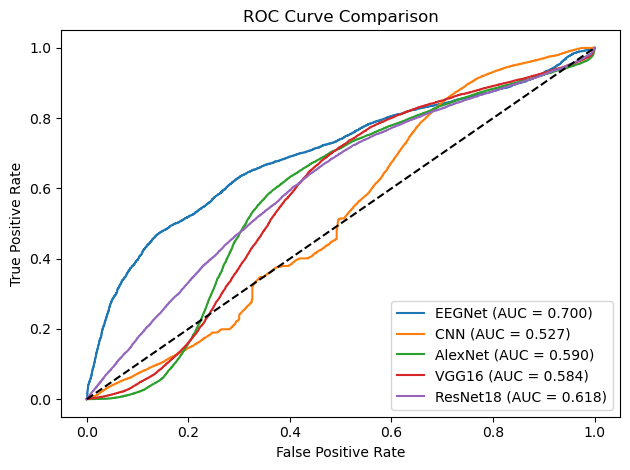

In [65]:
# Plot ROC curves
for model_name, results in models_ftd.items():
    fpr, tpr, auc_val = get_all_roc(results)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.legend(loc='lower right')
plt.savefig("figures/FTD_CN_models_ROC_curve_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [67]:
# Compile test accuracies across models
df_accuracy = []

for model_name, results in models_ftd.items():
    test_accuracies = get_all_accuracy(results)

    df_acc = pd.DataFrame(test_accuracies)
    df_acc["model"] = model_name
    df_acc["subject_group"] = df_acc["subject_group"].replace({"F": "FTD", "C": "CN"})
    
    df_accuracy.append(df_acc)

df_ftd = pd.concat(df_accuracy, ignore_index=True)
df_ftd.head()

,test_accuracy,test_subject_id,subject_group,model
0,1.000000,sub-037,CN,EEGNet
1,0.693694,sub-038,CN,EEGNet
2,0.924528,sub-039,CN,EEGNet
3,0.785863,sub-040,CN,EEGNet
4,0.936652,sub-041,CN,EEGNet


C:\Users\xiaox\AppData\Local\Temp\ipykernel_38036\846160546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ftd, x="model", y="test_accuracy", estimator="mean", errorbar="se", capsize=0.1, palette=palette, alpha=0.7)
C:\Users\xiaox\AppData\Local\Temp\ipykernel_38036\846160546.py:2: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=df_ftd, x="model", y="test_accuracy", estimator="mean", errorbar="se", capsize=0.1, palette=palette, alpha=0.7)


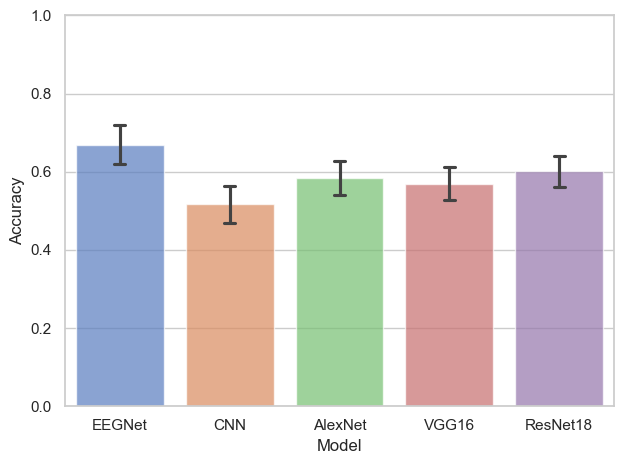

In [78]:
# Bar plot of model accuracies
sns.barplot(data=df_ftd, x="model", y="test_accuracy", estimator="mean", errorbar="se", capsize=0.1, palette=palette, alpha=0.7)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.savefig("figures/Model_Comparison_FTD_CN_Accuracies_Barplot.pdf", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

C:\Users\xiaox\AppData\Local\Temp\ipykernel_38036\776654114.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ftd, x="test_accuracy", y="model", palette=model_palette, cut=0, inner="box",  linewidth=1, density_norm="width")


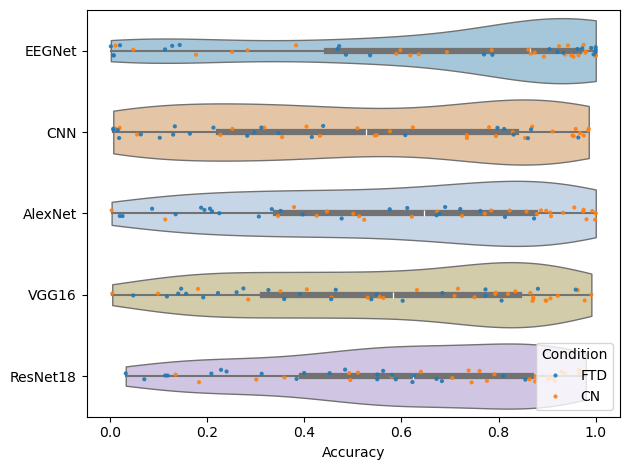

In [75]:
model_palette = {
    "EEGNet":   "#9ecae1",
    "CNN":      "#eec69c",
    "VGG16":    "#d9d0a3",
    "AlexNet":  "#c1d6ec",
    "ResNet18": "#cfc1e8"
    
}

dot_palette = {
    "FTD": "#1f77b4",
    "CN":  "#ff7f0e"
}

sns.violinplot(data=df_ftd, x="test_accuracy", y="model", palette=model_palette, cut=0, inner="box",  linewidth=1, density_norm="width")
sns.stripplot(data=df_ftd, x="test_accuracy", y="model", hue="subject_group", hue_order=["FTD", "CN"], palette=dot_palette, size=3, jitter=0.08, alpha=0.9)
plt.xlabel("Accuracy")
plt.ylabel("")
plt.legend(title="Condition", loc="lower right")
plt.tight_layout()
plt.savefig("figures/FTD_CN_final_violin_grouped.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
# Statistical comparison using Wilcoxon signed-rank test for paired samples
df_wide_ftd = df_ftd.pivot(index="test_subject_id", columns="model", values="test_accuracy")
for model_a, model_b in combinations(df_wide_ftd.columns, 2):
    stat, p = wilcoxon(df_wide_ftd[model_a], df_wide_ftd[model_b])
    print(f"{model_a} vs {model_b}: Wilcoxon statistic = {stat:.4f}, p = {p:.4f}")

AlexNet vs CNN: Wilcoxon statistic = 506.0000, p = 0.0956
AlexNet vs EEGNet: Wilcoxon statistic = 479.0000, p = 0.0558
AlexNet vs ResNet18: Wilcoxon statistic = 583.0000, p = 0.4533
AlexNet vs VGG16: Wilcoxon statistic = 573.0000, p = 0.2908
CNN vs EEGNet: Wilcoxon statistic = 355.0000, p = 0.0024
CNN vs ResNet18: Wilcoxon statistic = 477.0000, p = 0.0535
CNN vs VGG16: Wilcoxon statistic = 567.0000, p = 0.2665
EEGNet vs ResNet18: Wilcoxon statistic = 521.0000, p = 0.1260
EEGNet vs VGG16: Wilcoxon statistic = 428.0000, p = 0.0175
ResNet18 vs VGG16: Wilcoxon statistic = 540.0000, p = 0.1748
